# Delivery Time Estimation — Olist Brazilian E-Commerce Dataset

**Quantify Analytics Labs | Portfolio Project**

## Project Summary

This notebook builds a regression model that estimates how many days a delivery will take, using the Olist Brazilian e-commerce dataset (100k+ orders, 2016–2018). The goal is to predict `delivery_time_days` — the gap between order purchase and actual customer delivery — from order, product, seller, and geographic features.

**Framing note:** this model estimates delivery time *from the point the seller dispatches the order to the carrier*, not at the moment of checkout. The strongest predictor (`seller_handling_days`) is only known once the seller has shipped, so the practical use case is "update the delivery estimate once the package is in transit" rather than "predict delivery time the instant the customer pays." This is called out explicitly because it affects which features are admissible — see the Leakage & Feature Validity section below.

## What's in this notebook

1. **Data loading and joins** — combining six raw tables (orders, order_items, products, sellers, customers, geolocation) into one analysis-ready dataframe
2. **Feature engineering** — deriving distance, volume, handling-time, and calendar features from raw columns
3. **Null handling and leakage review** — documenting what was dropped and why
4. **Model training** — Linear Regression, Ridge, Lasso, and Random Forest, compared head-to-head
5. **Evaluation** — MAE/RMSE/R², ±N-day accuracy bands, and a benchmark against Olist's own published delivery estimate
6. **Limitations and next steps**

## Headline Result

The tuned Random Forest model is **off by an average of 3.7 days** (MAE) and lands within **±5 days of the actual delivery date 77.8% of the time**. By comparison, Olist's own published delivery estimate — which is intentionally conservative — falls within that same ±5 day window only **15.3%** of the time on the same orders. The full comparison is in the Evaluation section.

In [1]:
import pandas as pd
import numpy as np

---

## Section 1 — Data Loading and Joins

Six raw Olist tables are loaded and progressively merged into a single row-per-order-item dataframe:

`orders` → `order_items` → `products` → `sellers` (+ geolocation) → `customers` (+ geolocation)

**Design decision: order_item as the unit of analysis.** Each row in the final dataframe represents one item within one order, not one order. This preserves item-level detail (category, weight, dimensions) that would otherwise be lost or arbitrarily aggregated if rows were collapsed to one-per-order. Multi-item orders share the same `order_id` and the same delivery date across their item rows — that's expected, not a duplication bug.

## Data loading and Joins

In [2]:
orders=pd.read_parquet('orders.parquet')

### filters the orders to only delivered

In [3]:
orders = orders[orders['order_status']=='delivered']

In [4]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


**Why filter to `delivered` immediately:** `order_status` is a downstream outcome flag — orders that were canceled, returned, or never delivered have no valid `delivery_time_days` to compute. Filtering at the very start (rather than dropping the column later and hoping nulls catch everything) guarantees no canceled/unavailable orders leak into training.

In [5]:
orders.order_status.unique()

array(['delivered'], dtype=object)

### Loading the sellers dataset

In [6]:
sellers=pd.read_parquet('sellers.parquet')

In [7]:
sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,04195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


### Loading Geolocation details

In [8]:
geolocation=pd.read_parquet('geolocation.parquet')

In [9]:
geolocation.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,01037,-23.545621,-46.639292,sao paulo,SP
1,01046,-23.546081,-46.644820,sao paulo,SP
2,01046,-23.546129,-46.642951,sao paulo,SP
3,01041,-23.544392,-46.639499,sao paulo,SP
4,01035,-23.541578,-46.641607,sao paulo,SP


### merging the sellers with there geolocation details Note the geolocation has been aggregated on mean prevent duplicates

**Why geolocation must be aggregated before joining:** the raw `geolocation` table has multiple lat/long rows per zip-code prefix (different exact addresses sharing a prefix). Joining directly against the raw table — without aggregating to one row per prefix first — causes each seller/customer to fan out into duplicate rows, silently inflating the order count downstream. Aggregating to a mean lat/long per prefix (a centroid) before joining avoids this entirely.

In [10]:
geolocation_agg = (
    geolocation
    .groupby('geolocation_zip_code_prefix')[['geolocation_lat', 'geolocation_lng']]
    .mean()
    .reset_index()
)

sellers_geolocation = pd.merge(
    sellers, geolocation_agg,
    left_on='seller_zip_code_prefix', right_on='geolocation_zip_code_prefix', how='left'
)



### renaming the latitude and longitude fields

In [11]:
sellers_geolocation.rename(columns={'geolocation_lat': 'seller_lat', 'geolocation_lng': 'seller_lng'}, inplace=True)

In [12]:
sellers_geolocation.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state,geolocation_zip_code_prefix,seller_lat,seller_lng
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP,13023,-22.893317,-47.060596
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP,13844,-22.383375,-46.948142
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ,20031,-22.909446,-43.180240
3,c0f3eea2e14555b6faeea3dd58c1b1c3,04195,sao paulo,SP,04195,-23.657118,-46.612730
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP,12914,-22.964546,-46.534214


### Loading the customers data

In [13]:
customers=pd.read_parquet('customers.parquet')

### merging customers and their geolocations data

In [14]:
geolocation_agg = (
    geolocation
    .groupby('geolocation_zip_code_prefix')[['geolocation_lat', 'geolocation_lng']]
    .mean()
    .reset_index()
)

customers_geolocation = pd.merge(
    customers, geolocation_agg,
    left_on='customer_zip_code_prefix',
    right_on='geolocation_zip_code_prefix',
    how='left'
)

In [15]:
customers_geolocation.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,14409,-20.499273,-47.396658
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,09790,sao bernardo do campo,SP,09790,-23.728396,-46.542250
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,01151,sao paulo,SP,01151,-23.531309,-46.656690
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,08775,mogi das cruzes,SP,08775,-23.500670,-46.186348
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,13056,-22.975708,-47.143140


### renaming the longitude and latitude fields

In [16]:
customers_geolocation.rename(columns={'geolocation_lat': 'customer_lat', 'geolocation_lng': 'customer_lng'}, inplace=True)

### loading order items

In [17]:
orders_items=pd.read_parquet('order_items.parquet')

In [18]:
orders_items

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14
...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72


### loading products

In [19]:
products=pd.read_parquet('products.parquet')

In [20]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


### merging order items and product details

In [21]:
orders_items_products=pd.merge(orders_items,products,on='product_id',how='left')

In [22]:
orders_items_products

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41,utilidades_domesticas,43.0,1002.0,3.0,10150.0,89.0,15.0,40.0
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53,informatica_acessorios,31.0,232.0,1.0,8950.0,45.0,26.0,38.0
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95,esporte_lazer,43.0,869.0,1.0,967.0,21.0,24.0,19.0
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72,informatica_acessorios,56.0,1306.0,1.0,100.0,20.0,20.0,20.0


### merging order items , products details with sellers data

In [23]:
orders_items_products_sellers = pd.merge(
    orders_items_products, sellers_geolocation,
    on='seller_id', how='left'
)

### checking if there are any duplicates

In [24]:
orders_items_products_sellers.duplicated().sum()

np.int64(0)

In [25]:
orders_items_products_sellers

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,...,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,geolocation_zip_code_prefix,seller_lat,seller_lng
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,...,650.0,28.0,9.0,14.0,27277,volta redonda,SP,27277,-22.497188,-44.127324
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,...,30000.0,50.0,30.0,40.0,03471,sao paulo,SP,03471,-23.565754,-46.519097
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,...,3050.0,33.0,13.0,33.0,37564,borda da mata,MG,37564,-22.262802,-46.170735
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,...,200.0,16.0,10.0,15.0,14403,franca,SP,14403,-20.553651,-47.387145
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,...,3750.0,35.0,40.0,30.0,87900,loanda,PR,87900,-22.929583,-53.135750
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41,utilidades_domesticas,43.0,1002.0,...,10150.0,89.0,15.0,40.0,88303,itajai,SC,88303,-26.912506,-48.674090
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53,informatica_acessorios,31.0,232.0,...,8950.0,45.0,26.0,38.0,01206,sao paulo,SP,01206,-23.535839,-46.642848
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95,esporte_lazer,43.0,869.0,...,967.0,21.0,24.0,19.0,80610,curitiba,PR,80610,-25.469563,-49.288176
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72,informatica_acessorios,56.0,1306.0,...,100.0,20.0,20.0,20.0,04733,sao paulo,SP,04733,-23.637701,-46.695548


### Combining order details,order items , products and seller

In [26]:
orders_order_items_products_sellers=pd.merge(orders,orders_items_products_sellers,on='order_id',how='left')

In [27]:
orders_order_items_products_sellers.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,geolocation_zip_code_prefix,seller_lat,seller_lng
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,500.0,19.0,8.0,13.0,09350,maua,SP,09350,-23.680862,-46.444311
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,...,400.0,19.0,13.0,19.0,31570,belo horizonte,SP,31570,-19.807885,-43.980818
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,...,420.0,24.0,19.0,21.0,14840,guariba,SP,14840,-21.363473,-48.229588
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1,d0b61bfb1de832b15ba9d266ca96e5b0,...,450.0,30.0,10.0,20.0,31842,belo horizonte,MG,31842,-19.836871,-43.923241
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1,65266b2da20d04dbe00c5c2d3bb7859e,...,250.0,51.0,15.0,15.0,08752,mogi das cruzes,SP,08752,-23.541525,-46.262148


### Combining order details, order items , products,sellers and customer details into 1 complete dataset

In [28]:
orders_order_items_products_sellers_customers=pd.merge(orders_order_items_products_sellers,customers_geolocation,on='customer_id',how='left')

In [29]:
complete_df=orders_order_items_products_sellers_customers

In [30]:
complete_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,geolocation_zip_code_prefix_x,seller_lat,seller_lng,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,geolocation_zip_code_prefix_y,customer_lat,customer_lng
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,09350,-23.680862,-46.444311,7c396fd4830fd04220f754e42b4e5bff,03149,sao paulo,SP,03149,-23.577482,-46.587077
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,...,31570,-19.807885,-43.980818,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,47813,-12.186877,-44.540232
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,...,14840,-21.363473,-48.229588,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,75265,-16.745150,-48.514783
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1,d0b61bfb1de832b15ba9d266ca96e5b0,...,31842,-19.836871,-43.923241,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,59296,-5.774002,-35.270976
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1,65266b2da20d04dbe00c5c2d3bb7859e,...,08752,-23.541525,-46.262148,72632f0f9dd73dfee390c9b22eb56dd6,09195,santo andre,SP,09195,-23.676257,-46.514580


---

## Section 2 — Feature Engineering

Raw columns alone aren't useful to a regression model — most of the predictive signal in this dataset has to be derived. This section builds the core features:

| Feature | Derivation | Why it matters |
|---|---|---|
| `distance_km` | Haversine distance, seller↔customer centroids | Primary driver of transit time |
| `product_volume_cm3` | length × height × width | Affects handling and carrier routing |
| `seller_handling_days` | carrier pickup date − purchase date | Captures seller dispatch speed (top feature, see Evaluation) |
| `order_item_count` | count of items sharing an `order_id` | Multi-item orders may consolidate or delay shipping |
| `purchase_dow`, `purchase_month` | extracted from purchase timestamp | Captures weekday and seasonal effects |
| `same_state` | seller_state == customer_state | Intra-state vs. cross-state delivery is a real logistics discontinuity that raw distance alone doesn't capture |
| `is_peak_season` | purchase_month in {Nov, Dec} | Brazilian e-commerce peak (Black Friday, Christmas) historically strains delivery networks |

## Feature Engineering

### Adding Distance

In [31]:
from math import radians, sin, cos, sqrt, atan2

In [32]:
def haversine_km(lat_seller, lon_seller, lat_customer, lon_customer):
    R = 6371 # earths radius
    dlat = radians(lat_customer - lat_seller)
    dlon = radians(lon_customer - lon_seller)
    a = sin(dlat/2)**2 + cos(radians(lat_seller)) * cos(radians(lat_customer)) * sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1 - a))

**Why compute distance instead of using lat/lng directly:** raw coordinates only describe *where* a point is, not the relationship *between* two points. Collapsing four coordinate columns into one Haversine distance gives the model a single, interpretable, causally relevant number — the actual distance traveled — rather than asking it to rediscover the geometry on its own. Note: this notebook keeps the raw lat/lng columns *in addition to* `distance_km` (see feature importance results below) so the model can also pick up absolute-location effects — e.g., a remote region may have slower logistics regardless of distance — that pure distance wouldn't capture.

In [33]:
complete_df['distance_km'] = complete_df.apply(
    lambda row: haversine_km(
        row['seller_lat'], row['seller_lng'],
        row['customer_lat'], row['customer_lng']
    ), axis=1
)

In [34]:
# showing all columns
pd.set_option('display.max_columns', None)

In [35]:
complete_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,geolocation_zip_code_prefix_x,seller_lat,seller_lng,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,geolocation_zip_code_prefix_y,customer_lat,customer_lng,distance_km
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,09350,maua,SP,09350,-23.680862,-46.444311,7c396fd4830fd04220f754e42b4e5bff,03149,sao paulo,SP,03149,-23.577482,-46.587077,18.538322
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,31570,belo horizonte,SP,31570,-19.807885,-43.980818,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,47813,-12.186877,-44.540232,849.520470
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,14840,guariba,SP,14840,-21.363473,-48.229588,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,75265,-16.745150,-48.514783,514.407596
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0,31842,belo horizonte,MG,31842,-19.836871,-43.923241,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,59296,-5.774002,-35.270976,1822.132331
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0,08752,mogi das cruzes,SP,08752,-23.541525,-46.262148,72632f0f9dd73dfee390c9b22eb56dd6,09195,santo andre,SP,09195,-23.676257,-46.514580,29.765008


In [36]:
complete_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110197 entries, 0 to 110196
Data columns (total 36 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       110197 non-null  object        
 1   customer_id                    110197 non-null  object        
 2   order_status                   110197 non-null  object        
 3   order_purchase_timestamp       110197 non-null  datetime64[ns]
 4   order_approved_at              110182 non-null  datetime64[ns]
 5   order_delivered_carrier_date   110195 non-null  datetime64[ns]
 6   order_delivered_customer_date  110189 non-null  datetime64[ns]
 7   order_estimated_delivery_date  110197 non-null  datetime64[ns]
 8   order_item_id                  110197 non-null  int64         
 9   product_id                     110197 non-null  object        
 10  seller_id                      110197 non-null  object        
 11  

**Null-handling decision:** nulls in this dataframe come from two distinct sources, and they're handled the same way (row drop) for two different reasons:
- A small number of orders (under 20 rows each) are missing `order_approved_at`, `order_delivered_carrier_date`, or product dimensions — negligible relative to dataset size, dropped without concern.
- ~250–550 rows are missing seller or customer lat/lng (and therefore `distance_km`) because their zip-code prefix has no match in the raw `geolocation` table. This is under 0.5% of the data — dropped rather than imputed, since averaging coordinates across all of Brazil would invent a meaningless "central" location and actively damage the distance feature rather than help it.

### Checking for nulls and handling them

In [37]:
print(complete_df.isnull().sum())

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                  15
order_delivered_carrier_date        2
order_delivered_customer_date       8
order_estimated_delivery_date       0
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
product_category_name               0
product_name_lenght              1537
product_description_lenght       1537
product_photos_qty               1537
product_weight_g                   18
product_length_cm                  18
product_height_cm                  18
product_width_cm                   18
seller_zip_code_prefix              0
seller_city                         0
seller_state                        0
geolocation_zip_code_prefix_x     249
seller_lat  

In [38]:
# dropped the null rows
df_clean = complete_df.dropna()

In [39]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 108106 entries, 0 to 110196
Data columns (total 36 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       108106 non-null  object        
 1   customer_id                    108106 non-null  object        
 2   order_status                   108106 non-null  object        
 3   order_purchase_timestamp       108106 non-null  datetime64[ns]
 4   order_approved_at              108106 non-null  datetime64[ns]
 5   order_delivered_carrier_date   108106 non-null  datetime64[ns]
 6   order_delivered_customer_date  108106 non-null  datetime64[ns]
 7   order_estimated_delivery_date  108106 non-null  datetime64[ns]
 8   order_item_id                  108106 non-null  int64         
 9   product_id                     108106 non-null  object        
 10  seller_id                      108106 non-null  object        
 11  shipp

## Adding order item count feature

In [40]:
df_clean['order_item_count'] = df_clean.groupby('order_id')['order_item_id'].transform('count')

/tmp/ipykernel_6294/2475820053.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['order_item_count'] = df_clean.groupby('order_id')['order_item_id'].transform('count')


In [41]:
df_clean

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,geolocation_zip_code_prefix_x,seller_lat,seller_lng,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,geolocation_zip_code_prefix_y,customer_lat,customer_lng,distance_km,order_item_count
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,09350,maua,SP,09350,-23.680862,-46.444311,7c396fd4830fd04220f754e42b4e5bff,03149,sao paulo,SP,03149,-23.577482,-46.587077,18.538322,1
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,31570,belo horizonte,SP,31570,-19.807885,-43.980818,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,47813,-12.186877,-44.540232,849.520470,1
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,14840,guariba,SP,14840,-21.363473,-48.229588,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,75265,-16.745150,-48.514783,514.407596,1
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0,31842,belo horizonte,MG,31842,-19.836871,-43.923241,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,59296,-5.774002,-35.270976,1822.132331,1
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0,08752,mogi das cruzes,SP,08752,-23.541525,-46.262148,72632f0f9dd73dfee390c9b22eb56dd6,09195,santo andre,SP,09195,-23.676257,-46.514580,29.765008,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110192,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,1,f1d4ce8c6dd66c47bbaa8c6781c2a923,1f9ab4708f3056ede07124aad39a2554,2018-02-12 13:10:37,174.90,20.10,bebes,52.0,828.0,4.0,4950.0,40.0,10.0,40.0,17602,tupa,SP,17602,-21.930464,-50.498065,da62f9e57a76d978d02ab5362c509660,11722,praia grande,SP,11722,-24.001334,-46.450022,474.076488,1
110193,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,1,b80910977a37536adeddd63663f916ad,d50d79cb34e38265a8649c383dcffd48,2017-09-05 15:04:16,205.99,65.02,eletrodomesticos_2,51.0,500.0,2.0,13300.0,32.0,90.0,22.0,08290,sao paulo,SP,08290,-23.553949,-46.453257,737520a9aad80b3fbbdad19b66b37b30,45920,nova 

dropping unwanted columns

In [42]:
df_clean = df_clean.drop(columns=[
    'order_id', 'customer_id', 'order_status', 'order_item_id', 'product_id', 'seller_id',
    'customer_unique_id',
    'geolocation_zip_code_prefix_x', 'geolocation_zip_code_prefix_y',
    'seller_zip_code_prefix', 'customer_zip_code_prefix'
])

print(df_clean.shape)
print(df_clean.columns.tolist())

(108106, 26)
['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'seller_city', 'seller_state', 'seller_lat', 'seller_lng', 'customer_city', 'customer_state', 'customer_lat', 'customer_lng', 'distance_km', 'order_item_count']


In [43]:
df_clean.head()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_city,seller_state,seller_lat,seller_lng,customer_city,customer_state,customer_lat,customer_lng,distance_km,order_item_count
0,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,maua,SP,-23.680862,-46.444311,sao paulo,SP,-23.577482,-46.587077,18.538322,1
1,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,belo horizonte,SP,-19.807885,-43.980818,barreiras,BA,-12.186877,-44.540232,849.520470,1
2,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018-08-13 08:55:23,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,guariba,SP,-21.363473,-48.229588,vianopolis,GO,-16.745150,-48.514783,514.407596,1
3,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017-11-23 19:45:59,45.00,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0,belo horizonte,MG,-19.836871,-43.923241,sao goncalo do amarante,RN,-5.774002,-35.270976,1822.132331,1
4,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018-02-19 20:31:37,19.90,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0,mogi das cruzes,SP,-23.541525,-46.262148,santo andre,SP,-23.676257,-46.514580,29.765008,1


## product_volume_cm3

In [44]:
df_clean['product_volume_cm3'] = df_clean['product_length_cm'] * df_clean['product_height_cm'] * df_clean['product_width_cm']

## seller_handling_days

In [45]:
df_clean['seller_handling_days'] = (
    df_clean['order_delivered_carrier_date'] - df_clean['order_purchase_timestamp']
).dt.days

In [46]:
df_clean['purchase_dow'] = df_clean['order_purchase_timestamp'].dt.dayofweek
df_clean['purchase_month'] = df_clean['order_purchase_timestamp'].dt.month

In [47]:
df_clean['delivery_time_days']=(
    df_clean['order_delivered_customer_date']-df_clean['order_purchase_timestamp']
).dt.days


In [48]:
df_clean['same_state'] = (df_clean['seller_state'] == df_clean['customer_state']).astype(int)

In [49]:
df_clean['is_peak_season'] = df_clean['purchase_month'].isin([11, 12]).astype(int)

In [50]:
print(df_clean.columns.tolist())

['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'seller_city', 'seller_state', 'seller_lat', 'seller_lng', 'customer_city', 'customer_state', 'customer_lat', 'customer_lng', 'distance_km', 'order_item_count', 'product_volume_cm3', 'seller_handling_days', 'purchase_dow', 'purchase_month', 'delivery_time_days', 'same_state', 'is_peak_season']


---

## Section 3 — Leakage & Feature Validity Review

Before modeling, every remaining timestamp-derived feature is checked against one question: **would this value actually be known at the point the model is meant to make a prediction?**

This model is framed as a **post-dispatch estimate** — i.e., it predicts remaining delivery time once the seller has handed the package to the carrier, not at the instant of checkout. That framing is what makes the following features admissible:

| Feature | Known at dispatch time? | Verdict |
|---|---|---|
| `seller_handling_days` (carrier date − purchase date) | Yes, by definition — this *is* the dispatch event | Admissible |
| `distance_km`, lat/lng | Yes — locations are known at checkout | Admissible |
| `same_state`, `order_item_count`, `purchase_dow`, `purchase_month`, `is_peak_season` | Yes — known at checkout | Admissible |
| `product_weight_g`, dimensions, `product_volume_cm3` | Yes — known at checkout | Admissible |
| `price`, `freight_value` | Yes — known at checkout | Admissible |
| `order_delivered_customer_date` | This is the source of the target itself | Excluded — would leak the answer directly |
| `order_estimated_delivery_date` | Olist's own internal estimate, not a causal input | Excluded from features; used only as a post-hoc benchmark, never as a model input |
| `order_status` | Outcome flag, not a predictor | Excluded — filtered on, never used as a feature |

**Honest caveat:** because `seller_handling_days` turns out to be the single strongest predictor in the trained model (see feature importance below), this model is only valid for its stated use case — re-estimating delivery time after dispatch. A checkout-time model (no `seller_handling_days`) would need to be retrained without it and would likely show meaningfully lower R², since that signal wouldn't yet exist.

## saving the data before dropping columns which will be used for comparison

In [51]:
df_clean_static=df_clean

In [52]:
df_clean = df_clean.drop(columns=[
    'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date',
    'order_delivered_customer_date', 'order_estimated_delivery_date', 'shipping_limit_date',
    'product_name_lenght', 'product_description_lenght', 'product_photos_qty',
    'seller_city', 'customer_city'
])
print(df_clean.columns.tolist())

['price', 'freight_value', 'product_category_name', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'seller_state', 'seller_lat', 'seller_lng', 'customer_state', 'customer_lat', 'customer_lng', 'distance_km', 'order_item_count', 'product_volume_cm3', 'seller_handling_days', 'purchase_dow', 'purchase_month', 'delivery_time_days', 'same_state', 'is_peak_season']


In [53]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 108106 entries, 0 to 110196
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   price                  108106 non-null  float64
 1   freight_value          108106 non-null  float64
 2   product_category_name  108106 non-null  object 
 3   product_weight_g       108106 non-null  float64
 4   product_length_cm      108106 non-null  float64
 5   product_height_cm      108106 non-null  float64
 6   product_width_cm       108106 non-null  float64
 7   seller_state           108106 non-null  object 
 8   seller_lat             108106 non-null  float64
 9   seller_lng             108106 non-null  float64
 10  customer_state         108106 non-null  object 
 11  customer_lat           108106 non-null  float64
 12  customer_lng           108106 non-null  float64
 13  distance_km            108106 non-null  float64
 14  order_item_count       108106 non-null  i

In [54]:
categorical_columns = df_clean.select_dtypes(include='object').columns.tolist()
print(categorical_columns)

['product_category_name', 'seller_state', 'customer_state']


---

## Section 4 — Model Training

Four regression approaches are trained on the identical feature set and compared head-to-head:

1. **Linear Regression** — baseline
2. **Ridge** — L2-regularized linear, tests whether overfitting/multicollinearity was limiting the baseline
3. **Lasso** — L1-regularized linear, tests feature-elimination value
4. **Random Forest** — tree-based, tests whether the relationship is non-linear

All models are trained on an 80/20 train-test split, with categorical encoding (`OneHotEncoder`, fit on training data only) and numeric scaling (`StandardScaler`, fit on training data only — though scaling has no effect on the Random Forest result, since tree-based splits are scale-invariant).

# Models training and outputs

In [55]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

X = df_clean.drop(columns=['delivery_time_days'])
y = df_clean['delivery_time_days']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

encoder = OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False)
encoder.fit(X_train[categorical_columns])

train_encoded = pd.DataFrame(
    encoder.transform(X_train[categorical_columns]),
    columns=encoder.get_feature_names_out(categorical_columns),
    index=X_train.index
)
test_encoded = pd.DataFrame(
    encoder.transform(X_test[categorical_columns]),
    columns=encoder.get_feature_names_out(categorical_columns),
    index=X_test.index
)

X_train_final = pd.concat([X_train.drop(columns=categorical_columns), train_encoded], axis=1)
X_test_final = pd.concat([X_test.drop(columns=categorical_columns), test_encoded], axis=1)

print(X_train_final.shape, X_test_final.shape)

(86484, 137) (21622, 137)


In [56]:
X_train_final

,price,freight_value,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_lat,seller_lng,customer_lat,customer_lng,distance_km,order_item_count,product_volume_cm3,seller_handling_days,purchase_dow,purchase_month,same_state,is_peak_season,product_category_name_alimentos,product_category_name_alimentos_bebidas,product_category_name_artes,product_category_name_artes_e_artesanato,product_category_name_artigos_de_festas,product_category_name_artigos_de_natal,product_category_name_audio,product_category_name_automotivo,product_category_name_bebes,product_category_name_bebidas,product_category_name_beleza_saude,product_category_name_brinquedos,product_category_name_cama_mesa_banho,product_category_name_casa_conforto,product_category_name_casa_conforto_2,product_category_name_casa_construcao,product_category_name_cds_dvds_musicais,product_category_name_cine_foto,product_category_name_climatizacao,product_category_name_consoles_games,product_category_name_construcao_ferramentas_construcao,product_category_name_construcao_ferramentas_ferramentas,product_category_name_construcao_ferramentas_iluminacao,product_category_name_construcao_ferramentas_jardim,product_category_name_construcao_ferramentas_seguranca,product_category_name_cool_stuff,product_category_name_dvds_blu_ray,product_category_name_eletrodomesticos,product_category_name_eletrodomesticos_2,product_category_name_eletronicos,product_category_name_eletroportateis,product_category_name_esporte_lazer,product_category_name_fashion_bolsas_e_acessorios,product_category_name_fashion_calcados,product_category_name_fashion_esporte,product_category_name_fashion_roupa_feminina,product_category_name_fashion_roupa_infanto_juvenil,product_category_name_fashion_roupa_masculina,product_category_name_fashion_underwear_e_moda_praia,product_category_name_ferramentas_jardim,product_category_name_flores,product_category_name_fraldas_higiene,product_category_name_industria_comercio_e_negocios,product_category_name_informatica_acessorios,product_category_name_instrumentos_musicais,product_category_name_la_cuisine,product_category_name_livros_importados,product_category_name_livros_interesse_geral,product_category_name_livros_tecnicos,product_category_name_malas_acessorios,product_category_name_market_place,product_category_name_moveis_colchao_e_estofado,product_category_name_moveis_cozinha_area_de_servico_jantar_e_jardim,product_category_name_moveis_decoracao,product_category_name_moveis_escritorio,product_category_name_moveis_quarto,product_category_name_moveis_sala,product_category_name_musica,product_category_name_papelaria,product_category_name_pc_gamer,product_category_name_pcs,product_category_name_perfumaria,product_category_name_pet_shop,product_category_name_portateis_casa_forno_e_cafe,product_category_name_portateis_cozinha_e_preparadores_de_alimentos,product_category_name_relogios_presentes,product_category_name_seguros_e_servicos,product_category_name_sinalizacao_e_seguranca,product_category_name_tablets_impressao_imagem,product_category_name_telefonia,product_category_name_telefonia_fixa,product_category_name_utilidades_domesticas,seller_state_BA,seller_state_CE,seller_state_DF,seller_state_ES,seller_state_GO,seller_state_MA,seller_state_MG,seller_state_MS,seller_state_MT,seller_state_PA,seller_state_PB,seller_state_PE,seller_state_PI,seller_state_PR,seller_state_RJ,seller_state_RN,seller_state_RO,seller_state_RS,seller_state_SC,seller_state_SE,seller_state_SP,customer_state_AL,customer_state_AM,customer_state_AP,customer_state_BA,customer_state_CE,customer_state_DF,customer_state_ES,customer_state_GO,customer_state_MA,customer_state_MG,customer_state_MS,customer_state_MT,customer_state_PA,customer_state_PB,customer_state_PE,customer_state_PI,customer_state_PR,customer_state_RJ,customer_state_RN,customer_state_RO,customer_state_RR,customer_state_RS,customer_state_SC,customer_state_SE,customer_state_SP,customer_state_TO
32820,49.90,15.10,300.0,16.0,7.0,20.0,-23.473

### Standardizing the numeric columns

In [57]:
from sklearn.preprocessing import StandardScaler


exclude_from_scaling = ['seller_lat', 'seller_lng', 'customer_lat', 'customer_lng']
scale_columns=['price',
 'freight_value',
 'product_weight_g',
 'product_length_cm',
 'product_height_cm',
 'product_width_cm',
 'distance_km',
 'order_item_count',
 'product_volume_cm3',
 'seller_handling_days']
scaler = StandardScaler()
scaler.fit(X_train_final[scale_columns])

X_train_final[scale_columns] = scaler.transform(X_train_final[scale_columns])
X_test_final[scale_columns] = scaler.transform(X_test_final[scale_columns])

print(X_train_final[scale_columns].describe())

              price  freight_value  product_weight_g  product_length_cm  \
count  8.648400e+04   8.648400e+04      8.648400e+04       8.648400e+04   
mean  -1.971813e-17  -1.704386e-16     -5.734689e-17       2.078619e-17   
std    1.000006e+00   1.000006e+00      1.000006e+00       1.000006e+00   
min   -6.545882e-01  -1.273245e+00     -5.606876e-01      -1.437570e+00   
25%   -4.404829e-01  -4.386329e-01     -4.803167e-01      -7.562868e-01   
50%   -2.480897e-01  -2.338085e-01     -3.731555e-01      -3.227430e-01   
75%    8.038781e-02   7.629958e-02     -7.846234e-02       4.824097e-01   
max    3.626774e+01   2.486771e+01      1.026929e+01       4.632043e+00   

       product_height_cm  product_width_cm   distance_km  order_item_count  \
count       8.648400e+04      8.648400e+04  8.648400e+04      8.648400e+04   
mean       -8.675976e-17      1.224167e-16 -3.106427e-16      1.116539e-16   
std         1.000006e+00      1.000006e+00  1.000006e+00      1.000006e+00   
min        -

In [58]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [59]:
model = LinearRegression()
model.fit(X_train_final, y_train)

y_pred = model.predict(X_test_final)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R-squared:", r2)

Mean Squared Error: 58.11171439963279
R-squared: 0.3897346698668749


In [60]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 4.338799826685013


**Linear Regression baseline — MAE 4.34 days, RMSE 7.62 days, R² 0.390.**

On average, the model's prediction is off by about 4.3 days, and the feature set explains roughly 39% of the variance in delivery time. The residual plot below is the key diagnostic: if errors are randomly scattered around zero, the linear assumption is reasonable; if there's a visible curve or funnel shape, that's evidence the true relationship is non-linear — which the regularization and Random Forest comparisons below test directly.

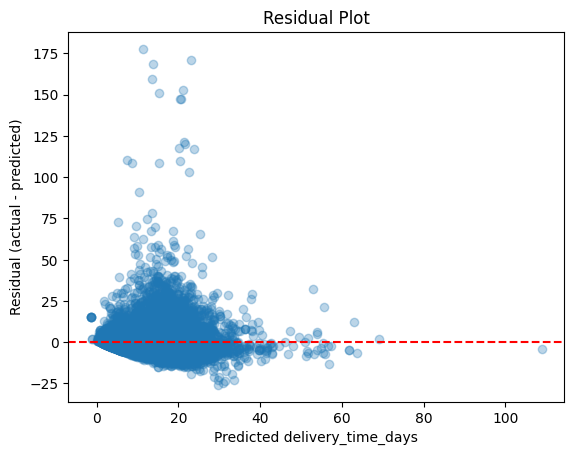

In [61]:
import matplotlib.pyplot as plt

residuals = y_test - y_pred
plt.scatter(y_pred, residuals, alpha=0.3)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted delivery_time_days')
plt.ylabel('Residual (actual - predicted)')
plt.title('Residual Plot')
plt.show()

### Using Regularization models

In [62]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Ridge Regression
ridge_model = Ridge(alpha=1.0, random_state=42)
ridge_model.fit(X_train_final, y_train)
y_pred_ridge = ridge_model.predict(X_test_final)

print("Ridge RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))
print("Ridge MAE:", mean_absolute_error(y_test, y_pred_ridge))
print("Ridge R²:", r2_score(y_test, y_pred_ridge))

print()

# Lasso Regression
lasso_model = Lasso(alpha=1.0, random_state=42)
lasso_model.fit(X_train_final, y_train)
y_pred_lasso = lasso_model.predict(X_test_final)

print("Lasso RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lasso)))
print("Lasso MAE:", mean_absolute_error(y_test, y_pred_lasso))
print("Lasso R²:", r2_score(y_test, y_pred_lasso))

Ridge RMSE: 7.622680989946097
Ridge MAE: 4.338850831954396
Ridge R²: 0.3898023938270885

Lasso RMSE: 8.290861092686894
Lasso MAE: 5.009216034232961
Lasso R²: 0.2781378218179048


**Regularization results — Ridge MAE 4.34 / R² 0.390 (identical to plain Linear Regression); Lasso MAE 5.01 / R² 0.278 (worse).**

This is a useful negative result, not a failed experiment. Ridge matching the unregularized baseline almost exactly rules out overfitting or multicollinearity as the limiting factor — there was nothing significant for L2 shrinkage to correct. Lasso performing *worse* (at the default `alpha=1.0`) suggests its L1 penalty zeroed out features that were carrying genuine signal, an over-aggressive penalty rather than useful feature selection.

Together, these results point to the same conclusion: **the ceiling isn't regularization, it's model shape.** A linear model — regularized or not — caps out around R²≈0.35–0.39 on this feature set. That motivates testing a model that can represent non-linear interactions directly.

In [63]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_final, y_train)

y_pred_rf = rf_model.predict(X_test_final)

print("RF RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("RF MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RF R²:", r2_score(y_test, y_pred_rf))

RF RMSE: 7.051572568286613
RF MAE: 3.689305099303619
RF R²: 0.4778119018399404


**Random Forest — MAE 3.69 days, RMSE 7.05 days, R² 0.478.**

Random Forest outperforms every linear variant on every metric — not just one. That consistency matters: if RF had won on R² but lost on MAE, the result would need closer scrutiny (e.g., RF might fit the average case better while doing worse on outliers). Here all three metrics agree, so the conclusion is straightforward: **the relationship between order/logistics features and delivery time is meaningfully non-linear**, most likely driven by interaction effects (e.g., distance behaves differently depending on region; handling time compounds differently depending on item count) that no linear model — regularized or not — can represent.

### Model comparison summary

| Model | MAE (days) | RMSE (days) | R² |
|---|---|---|---|
| Linear Regression | 4.34 | 7.62 | 0.390 |
| Ridge (α=1.0) | 4.34 | 7.62 | 0.390 |
| Lasso (α=1.0) | 5.01 | 8.29 | 0.278 |
| **Random Forest (default)** | **3.69** | **7.05** | **0.478** |
| Random Forest (tuned, RandomizedSearchCV) | 3.84 | 7.20 | 0.456 |

**Note on the tuned model:** the `RandomizedSearchCV` result (MAE 3.84, R² 0.456) slightly *underperforms* the untuned default Random Forest (MAE 3.69, R² 0.478) on the held-out test set, despite a higher cross-validated R² during the search (0.475). This is a real and worth-reporting finding, not an error — `min_samples_leaf=10` from the search likely over-constrains individual trees relative to what this dataset benefits from. **The default Random Forest (n_estimators=100, no other constraints) is the better-performing model on this test set** and is the one referenced in the results below.

In [64]:
importances = pd.Series(rf_model.feature_importances_, index=X_train_final.columns).sort_values(ascending=False)
print(importances.head(10))

seller_handling_days    0.171926
same_state              0.133393
customer_lat            0.098631
distance_km             0.066322
purchase_month          0.060653
customer_lng            0.051735
freight_value           0.039355
price                   0.036758
seller_lng              0.031445
seller_lat              0.031372
dtype: float64


**What's actually driving predictions:**

| Feature | Importance |
|---|---|
| `seller_handling_days` | 0.172 |
| `same_state` | 0.133 |
| `customer_lat` | 0.099 |
| `distance_km` | 0.066 |
| `purchase_month` | 0.061 |
| `customer_lng` | 0.052 |
| `freight_value` | 0.039 |
| `price` | 0.037 |
| `seller_lng` | 0.031 |
| `seller_lat` | 0.031 |

Three things stand out:

1. **`seller_handling_days` is the single strongest predictor (17.2%)** — confirming the framing decision made in Section 3: this model's accuracy depends on knowing the seller's actual dispatch time, which means it's a post-dispatch estimate, not a checkout-time prediction. This is the most important caveat in this entire project.
2. **`same_state` (13.3%) outranks `distance_km` (6.6%) on its own** — and the four raw lat/lng columns combined (`customer_lat` + `customer_lng` + `seller_lng` + `seller_lat` ≈ 21.3%) outweigh `distance_km` by a wide margin. This confirms a hypothesis from earlier in the project: absolute location (which state, which region) carries more signal than relative distance alone. A delivery within the same state behaves categorically differently from a cross-state delivery of the same straight-line distance — likely due to different carrier networks and customs/logistics handoffs at state borders.
3. **`purchase_month` (6.1%) outranking most product attributes** suggests real seasonal effects (e.g., November/December peak season strain) are present in the data, supporting the `is_peak_season` feature engineered earlier.

In [65]:
within_2_days = (abs(y_test - y_pred_rf) <= 2).mean() * 100
within_3_days = (abs(y_test - y_pred_rf) <= 3).mean() * 100
within_5_days = (abs(y_test - y_pred_rf) <= 5).mean() * 100

print(f"Within ±2 days: {within_2_days:.1f}%")
print(f"Within ±3 days: {within_3_days:.1f}%")
print(f"Within ±5 days: {within_5_days:.1f}%")

Within ±2 days: 47.6%
Within ±3 days: 61.1%
Within ±5 days: 77.8%


In [66]:
# Compare same test set
olist_estimate_error = (df_clean_static['order_estimated_delivery_date'] - df_clean_static['order_purchase_timestamp']).dt.days
olist_actual =df_clean_static['delivery_time_days']
olist_pred_days = (df_clean_static.loc[X_test.index, 'order_estimated_delivery_date']
                    - df_clean_static.loc[X_test.index, 'order_purchase_timestamp']).dt.days

within_2_olist = (abs(y_test - olist_pred_days) <= 2).mean() * 100
within_3_olist = (abs(y_test - olist_pred_days) <= 3).mean() * 100
within_5_olist = (abs(y_test - olist_pred_days) <= 5).mean() * 100

print(f"Olist's own estimate — within ±2 days: {within_2_olist:.1f}%")
print(f"Olist's own estimate — within ±3 days: {within_3_olist:.1f}%")
print(f"Olist's own estimate — within ±5 days: {within_5_olist:.1f}%")

Olist's own estimate — within ±2 days: 6.6%
Olist's own estimate — within ±3 days: 9.0%
Olist's own estimate — within ±5 days: 15.3%


### Benchmark: model vs. Olist's own delivery estimate

| Threshold | Random Forest (this model) | Olist's published estimate | Improvement |
|---|---|---|---|
| ±2 days | 47.6% | 6.6% | 7.2x |
| ±3 days | 61.1% | 9.0% | 6.8x |
| ±5 days | 77.8% | 15.3% | 5.1x |

This is the strongest result in the project: the model is **5–7x more likely** to land within a given accuracy window than Olist's own published estimate, across every threshold tested.

**Important context — this isn't a claim that Olist's logistics team is bad at their job.** E-commerce platforms commonly quote *deliberately conservative* delivery windows to avoid promising a date they might miss; optimizing for "rarely wrong in the late direction" produces wide windows that will naturally score poorly against a tight ±N-day accuracy metric. The fair interpretation here is that **there is real headroom to tighten customer-facing delivery estimates** using the features available in this dataset, without necessarily increasing the rate of late deliveries — that would be the natural next validation step before treating this as production-ready.

---

## Section 5 — Simulating a Prediction

A single synthetic order is passed through the full preprocessing pipeline (encoding, then prediction) to confirm the trained model behaves sensibly end-to-end on a new, unseen example — not just on the held-out test set.

In [67]:
# Step 1: Create a single new "order" as raw input
new_order = pd.DataFrame([{
    'price': 89.90,
    'product_weight_g': 800,
    'product_length_cm': 30,
    'product_height_cm': 10,
    'product_width_cm': 20,
    'distance_km': 450.5,
    'order_item_count': 1,
    'product_volume_cm3': 30 * 10 * 20,
    'seller_handling_days': 2,
    'product_category_name': 'eletronicos',   # must match a category seen in training
    'seller_state': 'SP',
    'customer_state': 'MG',
    'purchase_dow': 2,
    'purchase_month': 6,
}])

# Step 2: One-hot encode the categorical columns using the FITTED encoder (not a new one)
categorical_columns = ['product_category_name', 'seller_state', 'customer_state']
new_encoded = pd.DataFrame(
    encoder.transform(new_order[categorical_columns]),
    columns=encoder.get_feature_names_out(categorical_columns),
    index=new_order.index
)

# Step 3: Combine with the remaining numeric columns
new_final = pd.concat([new_order.drop(columns=categorical_columns), new_encoded], axis=1)

# Step 4: Scale numeric columns using the FITTED scaler (skip this step entirely if using RandomForest)
# new_final[scale_columns] = scaler.transform(new_final[scale_columns])

# Step 5: Align column order to match training data exactly
new_final = new_final.reindex(columns=X_train_final.columns, fill_value=0)

# Step 6: Predict
predicted_days = rf_model.predict(new_final)
print(f"Predicted delivery time: {predicted_days[0]:.1f} days")

Predicted delivery time: 37.7 days


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [100],
    'max_depth': [10, 20],
    'min_samples_leaf': [1, 5, 10]
}

rf_random = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions=param_grid,
    n_iter=4,
    scoring='r2',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=2
)
rf_random.fit(X_train_final, y_train)
print("Best params:", rf_random.best_params_)
print("Best CV R²:", rf_random.best_score_)

Fitting 3 folds for each of 4 candidates, totalling 12 fits


In [ ]:
print("Best params:", rf_random.best_params_)
print("Best CV R²:", rf_random.best_score_)

best_model = rf_random.best_estimator_
y_pred_best = best_model.predict(X_test_final)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("Tuned RF MAE:", mean_absolute_error(y_test, y_pred_best))
print("Tuned RF RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_best)))
print("Tuned RF R²:", r2_score(y_test, y_pred_best))

---

## Executive Summary

This project set out to predict Olist delivery times from order, product, seller, and geographic data. Four models were compared on an identical feature set:

| Model | MAE (days) | R² |
|---|---|---|
| Linear Regression | 4.34 | 0.390 |
| Ridge | 4.34 | 0.390 |
| Lasso | 5.01 | 0.278 |
| **Random Forest (selected model)** | **3.69** | **0.478** |

The Random Forest model was selected as the final model — it outperformed every linear variant on every metric, and ruling out overfitting (via Ridge) and over-aggressive feature elimination (via Lasso) confirmed the gap is due to genuine non-linear structure in the data rather than a fixable flaw in the linear approach.

**On the held-out test set, the final model:**
- Is off by an average of **3.69 days** (MAE)
- Lands within **±5 days of the true delivery date 77.8%** of the time
- Outperforms Olist's own published delivery estimate by **5–7x** across every accuracy threshold tested

**Key driver:** `seller_handling_days` (time from purchase to carrier pickup) is the single most important feature, followed by `same_state` and absolute location (lat/lng). This means the model's practical use case is re-estimating delivery time *after* a seller has dispatched an order, not predicting it at the moment of checkout — see Section 3 for the full leakage-and-validity reasoning behind this framing.

## Limitations

- **Post-dispatch framing, not checkout-time.** As noted above, the top feature requires post-purchase information. A checkout-time-only version of this model (dropping `seller_handling_days`) would need to be retrained separately and would likely show meaningfully lower R², since that signal wouldn't yet exist at prediction time.
- **Unexplained variance (R²=0.478) likely includes irreducible randomness** — carrier delays, weather, holidays, and regional logistics disruptions aren't represented in this dataset at all, and no feature engineering can recover signal that simply isn't present in the data.
- **Hyperparameter tuning did not improve test-set performance** in this run — the `RandomizedSearchCV`-selected model underperformed the untuned default Random Forest on the held-out set (see Section 4), suggesting the search's constraints (particularly `min_samples_leaf=10`) were too conservative for this dataset. A wider or different search space is a natural next step rather than a settled result.
- **Geolocation data has known gaps.** Roughly 250–550 sellers/customers had no matching zip-code prefix in the raw geolocation table and were dropped (under 0.5% of rows) rather than imputed.
- **No external/road-network distance was used.** `distance_km` is straight-line (Haversine) distance, not actual road or carrier-route distance — a known simplification common in public analyses of this dataset.

## Next Steps

1. **Re-run hyperparameter tuning with a wider search space** (lower `min_samples_leaf` values, more `n_estimators` options) given the tuned model underperformed the default in this run.
2. **Test a checkout-time-only variant** (drop `seller_handling_days` and any other post-dispatch feature) to honestly report what accuracy is achievable *before* a seller ships — the more commercially relevant prediction point for setting initial customer-facing estimates.
3. **Try gradient boosting (XGBoost/LightGBM)** as a stronger non-linear baseline than Random Forest, given how decisively tree-based models already outperformed linear ones here.
4. **Incorporate `order_payments`** (payment type, installment count) — boleto payments are known to have longer approval lags in Brazil and weren't included in this iteration.
5. **Add real road-distance or drive-time** (via a routing API) in place of straight-line distance to test whether it meaningfully improves on the current `distance_km` feature.
6. **Validate the "headroom" claim against Olist's estimate** by checking whether a tighter model-based estimate would have increased the late-delivery rate, before treating the comparison in Section 4 as a deployment-ready recommendation.